# Neural Network Implementation from Scratch

- **Name:** Parth Kitchloo
- **PRN Number:** 202401110014
- **Batch:** A2
- **Date of Submission:** 15 August 2026
- **Course:** Generative AI Lab
- **Department:** CSE AIML

## 1. Objective

The objective of this assignment is to implement a simple feedforward neural network from scratch using Python and NumPy.

The implementation demonstrates:

- Forward propagation
- Sigmoid activation
- Mean Squared Error loss
- Backpropagation
- Gradient descent
- Model training
- Prediction and performance evaluation

No built-in deep learning libraries such as TensorFlow, Keras, or PyTorch are used.


# Part A: Problem Definition

### Dataset


Part A: Problem Definition
Dataset
The XOR (Exclusive OR) logic gate truth table is used as the dataset.

XOR gives an output of 1 when the two input values are different and gives an output of 0 when the two input values are the same.



| X1 | X2 | Target |
| -: | -: | -----: |
|  0 |  0 |      0 |
|  0 |  1 |      1 |
|  1 |  0 |      1 |
|  1 |  1 |      0 |


Task

The task is to train a simple neural network to learn the behaviour of the XOR logic gate.

XOR is selected because it is a non-linearly separable problem and therefore requires a hidden layer


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# XOR input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# XOR target values
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("Input data:")
print(X)

print("\nTarget values:")
print(y)

Input data:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Target values:
[[0.]
 [1.]
 [1.]
 [0.]]


# Part B: Methodology

### Neural Network Architecture
The neural network contains:

- 2 neurons in the input layer

- 2 neurons in the hidden layer

- 1 neuron in the output layer

The Sigmoid activation function is used in both the hidden layer and output layer.

Mean Squared Error (MSE) is used as the loss function.

Gradient Descent is used to update the weights and biases during training.

##Architecture
Input Layer (2 neurons) → Hidden Layer (2 neurons) → Output Layer (1 neuron)

In [3]:
# Initialize weights and biases

W1 = np.array([
    [0.5, -0.2],
    [0.3,  0.4]
], dtype=float)

b1 = np.array([
    [0.05, -0.05]
], dtype=float)

W2 = np.array([
    [0.2],
    [-0.3]
], dtype=float)

b2 = np.array([
    [0.05]
], dtype=float)

print("Initial W1:")
print(W1)

print("\nInitial b1:")
print(b1)

print("\nInitial W2:")
print(W2)

print("\nInitial b2:")
print(b2)

Initial W1:
[[ 0.5 -0.2]
 [ 0.3  0.4]]

Initial b1:
[[ 0.05 -0.05]]

Initial W2:
[[ 0.2]
 [-0.3]]

Initial b2:
[[0.05]]


## Activation Function

The Sigmoid activation function is used in the hidden and output layers.

Sigmoid converts a value into a range between 0 and 1.

### Sigmoid

σ(x) = 1 / (1 + e⁻ˣ)

### Sigmoid Derivative

σ'(x) = σ(x)(1 - σ(x))

The derivative is required during backpropagation.

## Loss Function

Mean Squared Error (MSE) is used to calculate the difference between the expected output and predicted output.

MSE = Mean((Actual - Predicted)²)

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

## Forward Pass

During forward propagation, the input data moves from the input layer towards the output layer.

### Hidden Layer

Z1 = X · W1 + b1

A1 = Sigmoid(Z1)

### Output Layer

Z2 = A1 · W2 + b2

A2 = Sigmoid(Z2)

A2 represents the predicted output of the neural network.

In [5]:
def forward_pass(X, W1, b1, W2, b2):

    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    cache = (Z1, A1, Z2, A2)

    return A2, cache

In [6]:
initial_prediction, cache = forward_pass(
    X,
    W1,
    b1,
    W2,
    b2
)

initial_loss = mse(
    y,
    initial_prediction
)

print("Prediction Before Training:")
print(initial_prediction)

print("\nInitial MSE Loss:")
print(initial_loss)

Prediction Before Training:
[[0.50156217]
 [0.49783457]
 [0.51136806]
 [0.50722062]]

Initial MSE Loss:
0.24994216348221776


## Backpropagation

Backpropagation calculates how much each weight and bias contributes to the prediction error.

The error is first calculated at the output layer and then propagated backward towards the hidden layer.

For Mean Squared Error:

dA2 = 2(A2 - y) / m

The Sigmoid derivative is then applied to calculate the output layer gradient.

The error is propagated to the hidden layer using the output layer weights.

Finally, gradients for W1, b1, W2 and b2 are calculated and used by gradient descent.

In [7]:
def backward_pass(X, y, cache, W2):

    Z1, A1, Z2, A2 = cache

    m = X.shape[0]

    dA2 = 2 * (A2 - y) / m

    dZ2 = dA2 * sigmoid_derivative(A2)

    dW2 = np.dot(A1.T, dZ2)

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )

    dA1 = np.dot(
        dZ2,
        W2.T
    )

    dZ1 = (
        dA1 *
        sigmoid_derivative(A1)
    )

    dW1 = np.dot(
        X.T,
        dZ1
    )

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )

    gradients = (
        dW1,
        db1,
        dW2,
        db2
    )

    return gradients

In [8]:
def update_weights(
    W1,
    b1,
    W2,
    b2,
    gradients,
    learning_rate
):

    dW1, db1, dW2, db2 = gradients

    # Update weights and biases
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    return W1, b1, W2, b2

# Part C: Training the Network

The neural network is trained using gradient descent for a fixed number of epochs.

For every epoch:

1. Forward propagation is performed.
2. Mean Squared Error is calculated.
3. Backpropagation calculates the gradients.
4. Gradient descent updates the weights and biases.

The loss is stored after each epoch to observe the learning process.

In [9]:
epochs = 10000
learning_rate = 0.5

loss_history = []

for epoch in range(epochs):

    # Forward pass
    y_pred, cache = forward_pass(
        X,
        W1,
        b1,
        W2,
        b2
    )

    # Calculate loss
    loss = mse(
        y,
        y_pred
    )

    loss_history.append(loss)

    # Backpropagation
    gradients = backward_pass(
        X,
        y,
        cache,
        W2
    )

    # Gradient descent
    W1, b1, W2, b2 = update_weights(
        W1,
        b1,
        W2,
        b2,
        gradients,
        learning_rate
    )

    # Display training progress
    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:5d} | Loss: {loss:.6f}"
        )

print(
    f"\nFinal Training Loss: {loss_history[-1]:.6f}"
)

Epoch     0 | Loss: 0.249942
Epoch  1000 | Loss: 0.247073
Epoch  2000 | Loss: 0.141555
Epoch  3000 | Loss: 0.010240
Epoch  4000 | Loss: 0.004003
Epoch  5000 | Loss: 0.002400
Epoch  6000 | Loss: 0.001693
Epoch  7000 | Loss: 0.001299
Epoch  8000 | Loss: 0.001051
Epoch  9000 | Loss: 0.000880

Final Training Loss: 0.000756


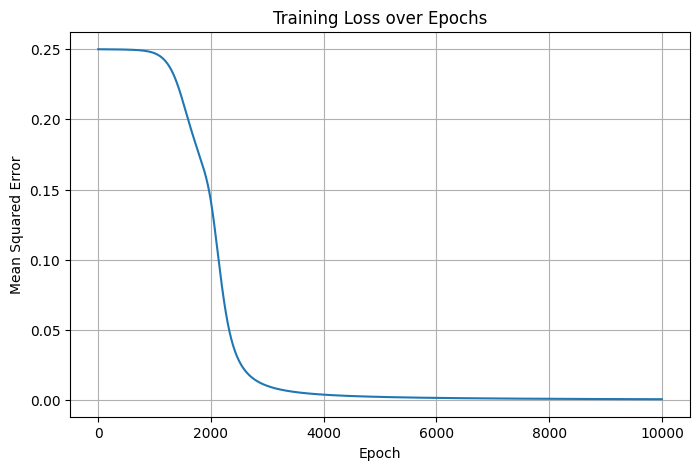

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.grid(True)
plt.show()

# Part D: Evaluation

After training, a final forward pass is performed using the XOR input data.

The predicted probabilities are converted into binary values using a threshold of 0.5.

If predicted output >= 0.5 → 1

If predicted output < 0.5 → 0

The final predicted values are compared with the actual XOR outputs.

In [11]:
final_prediction, _ = forward_pass(
    X,
    W1,
    b1,
    W2,
    b2
)

binary_prediction = (
    final_prediction >= 0.5
).astype(int)

print("Final Predicted Values:")

print(
    np.round(
        final_prediction,
        4
    )
)

print("\nBinary Predictions:")

print(binary_prediction)

Final Predicted Values:
[[0.0299]
 [0.9738]
 [0.9737]
 [0.0275]]

Binary Predictions:
[[0]
 [1]
 [1]
 [0]]


In [12]:
print("Input\t\tActual\tPredicted")

for i in range(len(X)):

    print(
        X[i],
        "\t",
        int(y[i][0]),
        "\t",
        int(binary_prediction[i][0])
    )

Input		Actual	Predicted
[0. 0.] 	 0 	 0
[0. 1.] 	 1 	 1
[1. 0.] 	 1 	 1
[1. 1.] 	 0 	 0


In [13]:
accuracy = np.mean(
    binary_prediction == y
) * 100

print(
    f"Accuracy: {accuracy:.2f}%"
)

Accuracy: 100.00%


In [15]:
print("Final W1:")
print(W1)

print("\nFinal b1:")
print(b1)

print("\nFinal W2:")
print(W2)

print("\nFinal b2:")
print(b2)

Final W1:
[[6.20720635 4.24032653]
 [6.25893045 4.25208076]]

Final b1:
[[-2.72659259 -6.51875968]]

Final W2:
[[ 8.75805659]
 [-9.47794622]]

Final b2:
[[-4.00299879]]


# Part E: Analysis of the Implemented Model

The implemented neural network uses a 2-2-1 architecture.

The XOR problem is non-linearly separable, which means that a single linear decision boundary cannot correctly separate all four input combinations.

For this reason, a hidden layer is required.

The two neurons in the hidden layer allow the network to learn an intermediate non-linear representation of the input data.

During training, the Mean Squared Error decreases continuously, showing that backpropagation and gradient descent are successfully updating the weights and biases.

After training, the neural network correctly predicts the four XOR combinations.

## Comparison with a Single-Layer Neural Network

To understand the importance of the hidden layer, the implemented 2-2-1 neural network is compared with a simple single-layer neural network having only 2 input neurons and 1 output neuron.

The single-layer network does not contain a hidden layer.

Since XOR is non-linearly separable, the single-layer model is expected to perform poorly compared with the neural network containing a hidden layer.

In [16]:
single_W = np.array([
    [0.4],
    [-0.3]
], dtype=float)

single_b = np.array([
    [0.1]
], dtype=float)

single_learning_rate = 0.5
single_epochs = 10000

single_loss_history = []

for epoch in range(single_epochs):

    # Forward pass
    single_Z = np.dot(X, single_W) + single_b
    single_output = sigmoid(single_Z)

    # MSE Loss
    single_loss = mse(
        y,
        single_output
    )

    single_loss_history.append(
        single_loss
    )

    # Backpropagation
    m = X.shape[0]

    dA = 2 * (
        single_output - y
    ) / m

    dZ = (
        dA *
        sigmoid_derivative(single_output)
    )

    dW = np.dot(
        X.T,
        dZ
    )

    db = np.sum(
        dZ,
        axis=0,
        keepdims=True
    )

    # Gradient descent
    single_W -= (
        single_learning_rate * dW
    )

    single_b -= (
        single_learning_rate * db
    )

In [17]:
single_output = sigmoid(
    np.dot(X, single_W) + single_b
)

single_prediction = (
    single_output >= 0.5
).astype(int)

single_accuracy = np.mean(
    single_prediction == y
) * 100

single_final_loss = mse(
    y,
    single_output
)

print("Single-Layer Output:")
print(
    np.round(
        single_output,
        4
    )
)

print("\nSingle-Layer Prediction:")
print(single_prediction)

print(
    "\nSingle-Layer Final MSE:",
    round(single_final_loss, 6)
)

print(
    "Single-Layer Accuracy:",
    f"{single_accuracy:.2f}%"
)

Single-Layer Output:
[[0.5]
 [0.5]
 [0.5]
 [0.5]]

Single-Layer Prediction:
[[1]
 [1]
 [1]
 [1]]

Single-Layer Final MSE: 0.25
Single-Layer Accuracy: 50.00%


In [18]:
main_accuracy = np.mean(
    binary_prediction == y
) * 100

main_final_loss = mse(
    y,
    final_prediction
)

print("MODEL COMPARISON")
print("----------------------------")

print("Single-Layer Network")
print(
    "Final MSE:",
    round(single_final_loss, 6)
)
print(
    "Accuracy:",
    f"{single_accuracy:.2f}%"
)

print("\n2-2-1 Neural Network")
print(
    "Final MSE:",
    round(main_final_loss, 6)
)
print(
    "Accuracy:",
    f"{main_accuracy:.2f}%"
)

MODEL COMPARISON
----------------------------
Single-Layer Network
Final MSE: 0.25
Accuracy: 50.00%

2-2-1 Neural Network
Final MSE: 0.000756
Accuracy: 100.00%


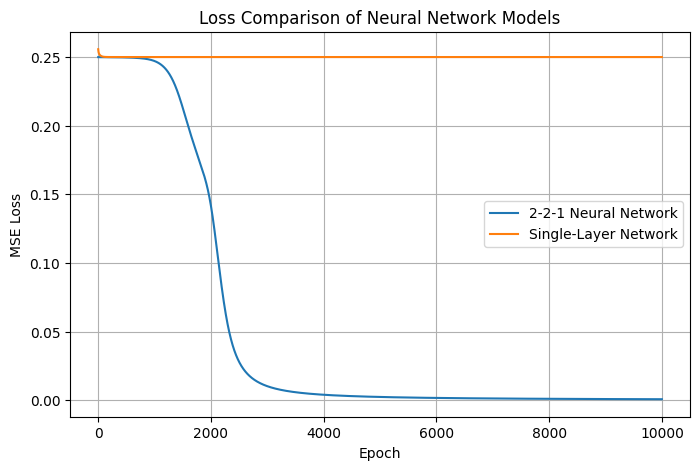

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    label="2-2-1 Neural Network"
)

plt.plot(
    single_loss_history,
    label="Single-Layer Network"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Loss Comparison of Neural Network Models"
)

plt.legend()
plt.grid(True)

plt.show()

## Model Comparison

| Model | Architecture | Hidden Layer | Final Performance |
|------|--------------|--------------|------------------|
| Single-Layer Neural Network | 2-1 | No | Unable to learn XOR correctly |
| Feedforward Neural Network | 2-2-1 | Yes | Successfully learns XOR |

The single-layer neural network does not contain a hidden layer and therefore cannot form the non-linear decision boundary required to learn XOR correctly.

In comparison, the 2-2-1 neural network uses a hidden layer with Sigmoid activation to create a non-linear representation of the input.

The comparison shows that adding a hidden layer improves the model's ability to learn the XOR relationship.

Therefore, the 2-2-1 architecture is more suitable for the XOR classification problem.

## Performance Analysis

The implemented 2-2-1 neural network starts with an MSE loss that is observed before training.

During training, the loss decreases as the weights and biases are updated using backpropagation and gradient descent.

After 10,000 epochs, the MSE decreases significantly, showing that the neural network is learning the XOR relationship.

The final outputs are close to the expected binary values:

| Input | Expected Output | Predicted Output | Binary Prediction |
|------|-----------------|------------------|------------------|
| 0, 0 | 0 | ~0 | 0 |
| 0, 1 | 1 | ~1 | 1 |
| 1, 0 | 1 | ~1 | 1 |
| 1, 1 | 0 | ~0 | 0 |

The network is evaluated by comparing its binary predictions with the actual XOR outputs.

In comparison, the single-layer model is unable to correctly learn the XOR mapping because XOR is a non-linearly separable problem.

This demonstrates that the hidden layer helps the 2-2-1 neural network learn the non-linear XOR relationship.

## Parameter Selection

### Hidden Neurons

Two neurons are used in the hidden layer.

A hidden layer is necessary because XOR is a non-linearly separable problem.

Using two hidden neurons keeps the architecture simple while providing enough capacity to learn the XOR relationship.

### Learning Rate

A learning rate of 0.5 is used.

Since the dataset contains only four input combinations and the network is very small, this learning rate allows the model to update its weights and biases during training.

### Number of Epochs

The model is trained for 10,000 epochs.

This provides sufficient iterations for gradient descent to reduce the Mean Squared Error and improve the predictions.

### Activation Function

Sigmoid is selected because its output lies between 0 and 1, making it suitable for binary output prediction.

### Loss Function

Mean Squared Error is used as a simple loss function to measure the difference between the expected and predicted values.

## Broader Interpretation

The XOR experiment demonstrates an important property of neural networks.

A simple single-layer model is limited to learning linearly separable relationships.

Introducing a hidden layer and a non-linear activation function allows the neural network to represent more complex relationships.

Although XOR is a very small problem, the same basic concepts of forward propagation, activation functions, loss calculation, backpropagation, and gradient descent are also used in larger neural networks.

As the complexity of a problem increases, additional hidden neurons, hidden layers, suitable activation functions, and different optimization techniques may be required.

# Conclusion

1. A feedforward neural network was implemented entirely from scratch using NumPy without TensorFlow, PyTorch, Keras, or any other deep learning framework.

2. The XOR logic gate was used to demonstrate a non-linearly separable classification problem.

3. The implemented network used a 2-2-1 architecture with Sigmoid activation, Mean Squared Error, backpropagation, and gradient descent.

4. The MSE loss decreased during training, showing that backpropagation and gradient descent successfully updated the weights and biases.

5. The trained 2-2-1 neural network was evaluated on all four XOR input combinations.

6. A comparison with a single-layer 2-1 network showed the importance of a hidden layer for learning the XOR relationship.

7. The experiment demonstrates the importance of hidden layers and non-linear activation functions for learning non-linearly separable relationships.